<a href="https://colab.research.google.com/github/challagullashravya-tech/ML-project-/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape of Dataset:
(59598, 24)

First 5 Rows:
   Employee ID  Age  Gender  Years at Company    Job Role  Monthly Income  \
0         8410   31    Male                19   Education            5390   
1        64756   59  Female                 4       Media            5534   
2        30257   24  Female                10  Healthcare            8159   
3        65791   36  Female                 7   Education            3989   
4        65026   56    Male                41   Education            4821   

  Work-Life Balance Job Satisfaction Performance Rating  Number of Promotions  \
0         Excellent           Medium            Average                     2   
1              Poor             High                Low                     3   
2              Good             High                Low                     0   
3              Good             High               High                     1   
4              Fair        Very High            Average                     0   

   ..

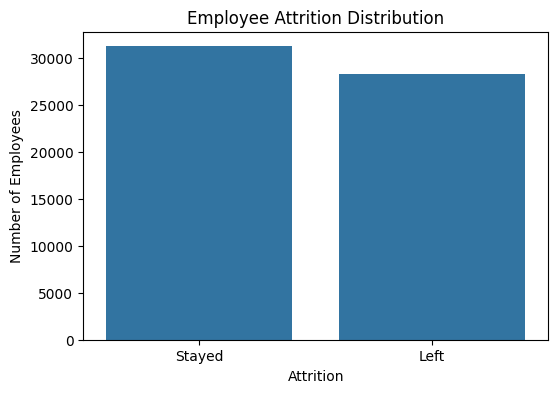


Attrition Percentage:
Attrition
Stayed    52.451425
Left      47.548575
Name: proportion, dtype: float64

Numerical Columns:
['Employee ID', 'Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']


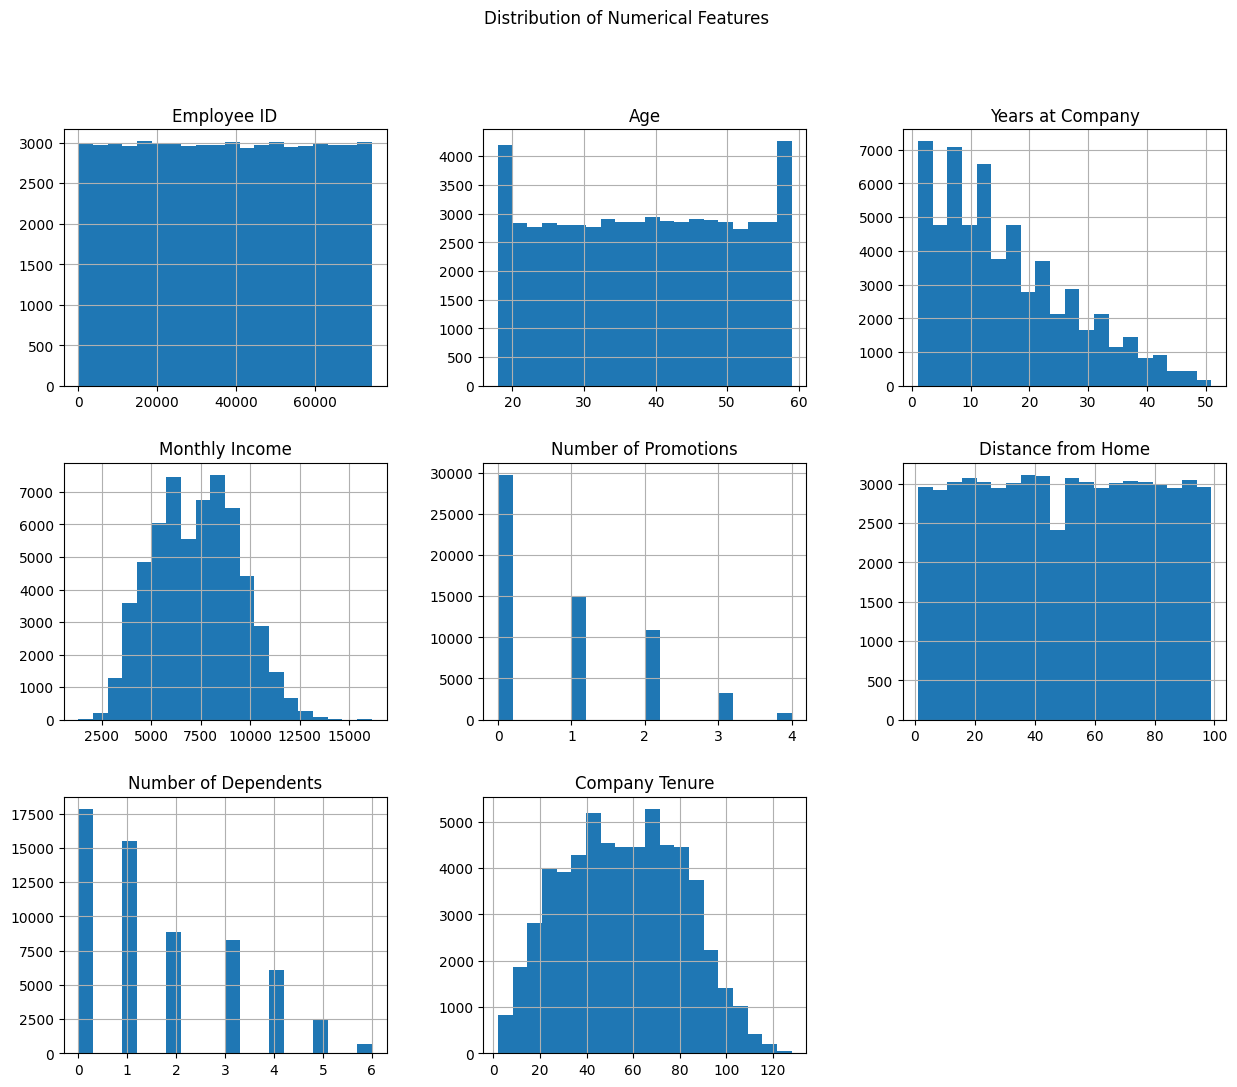

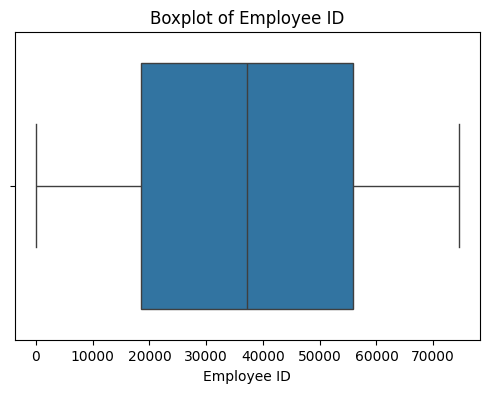

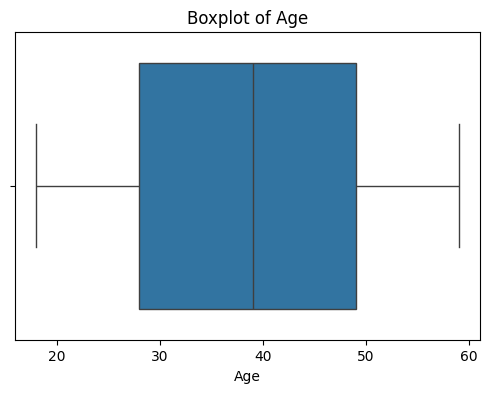

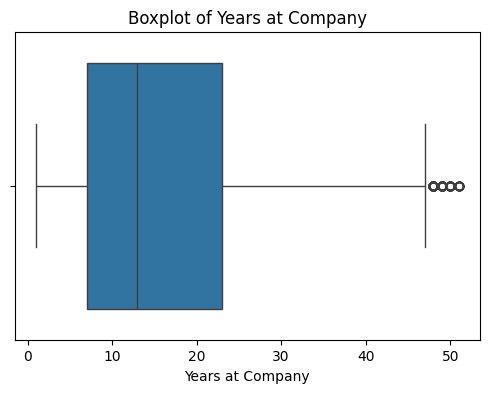

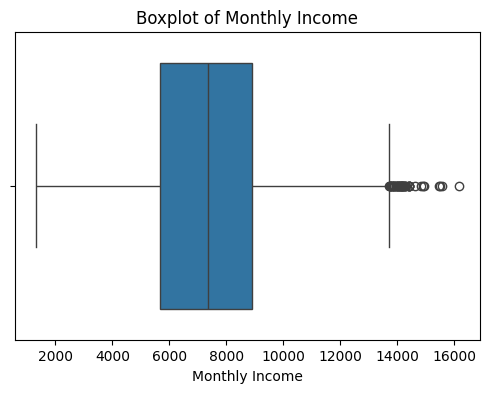

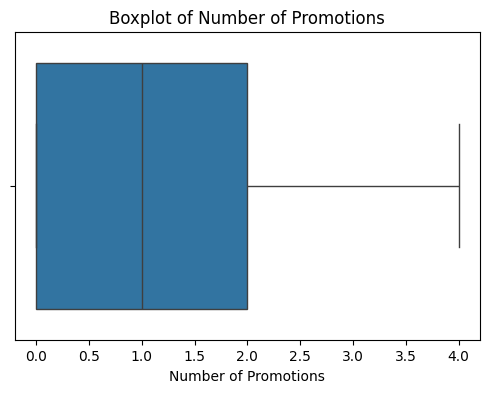

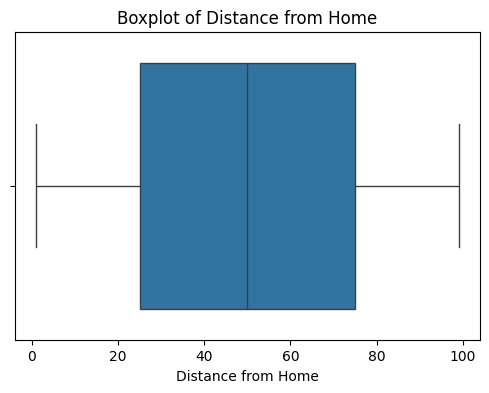

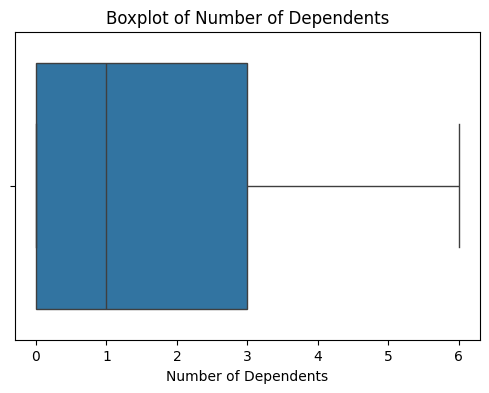

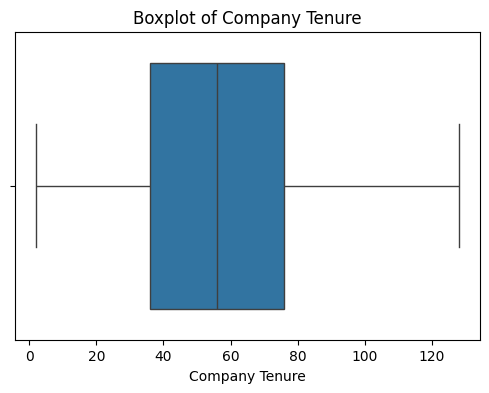


Categorical Columns:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


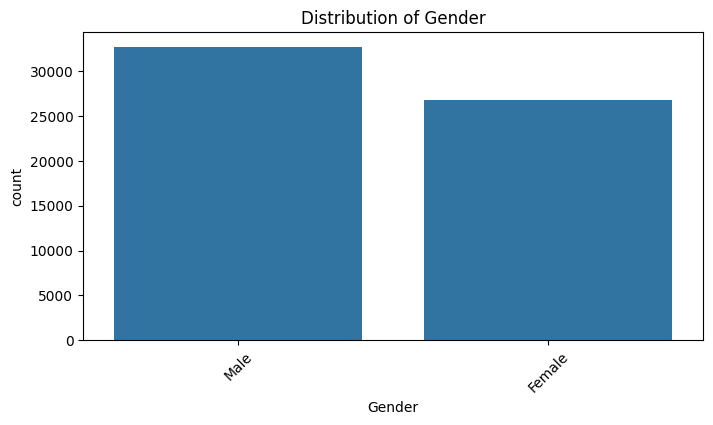

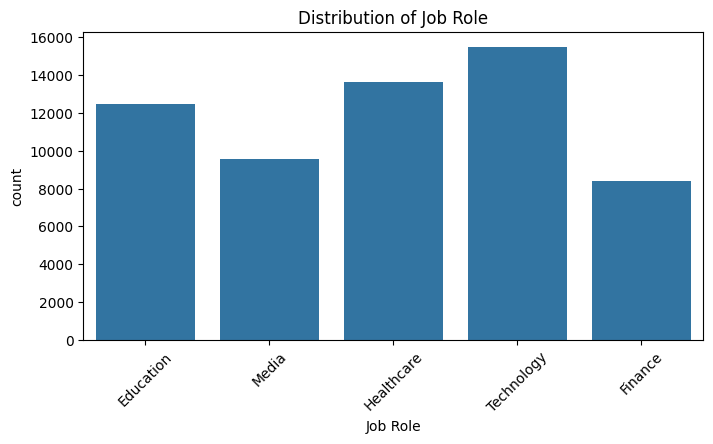

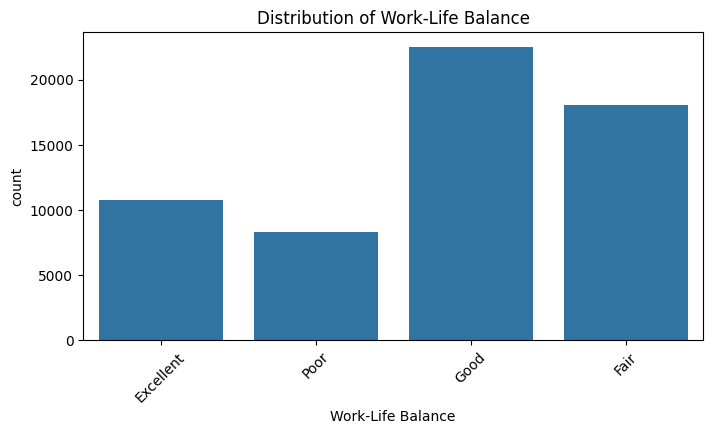

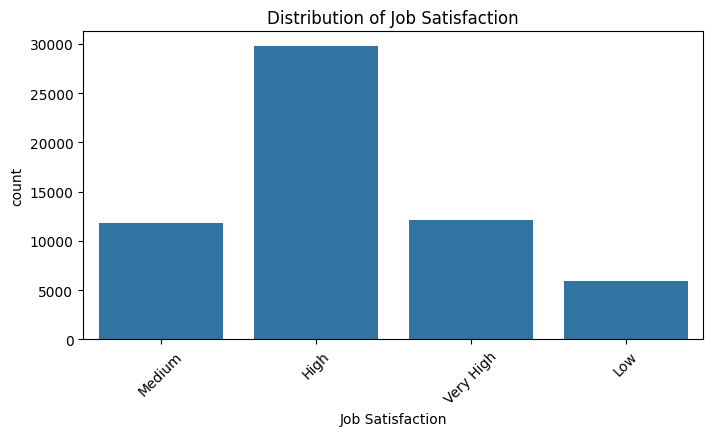

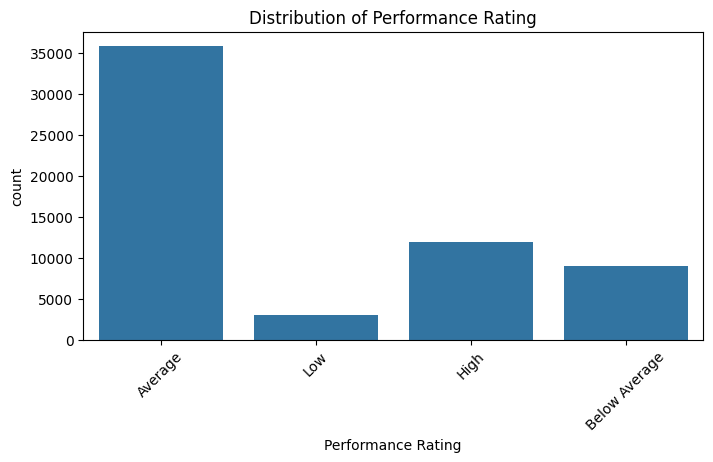

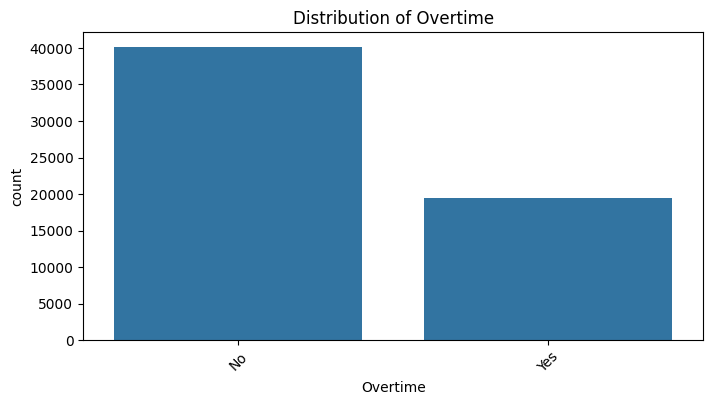

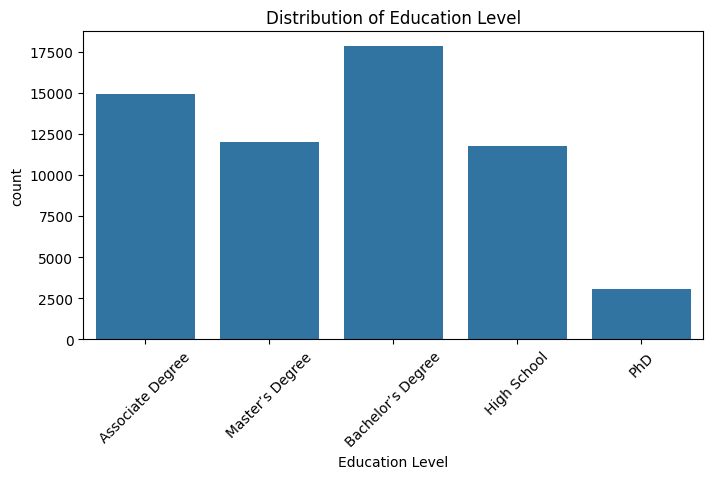

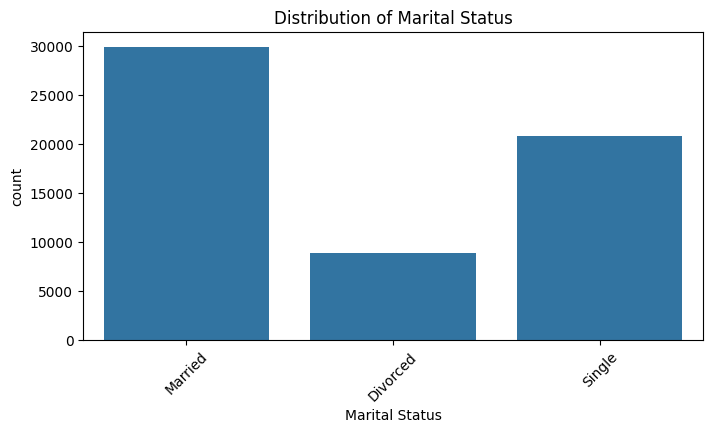

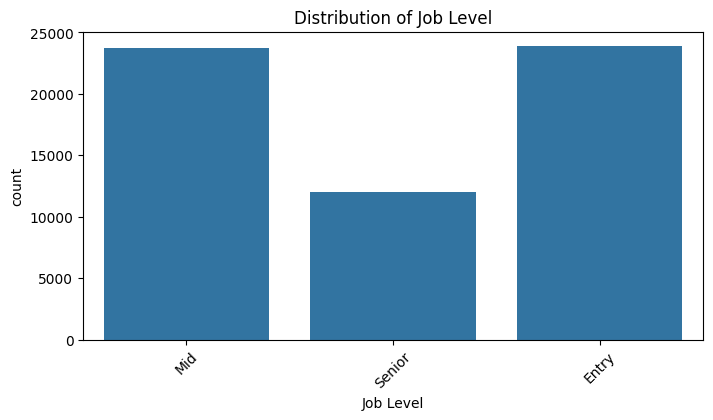

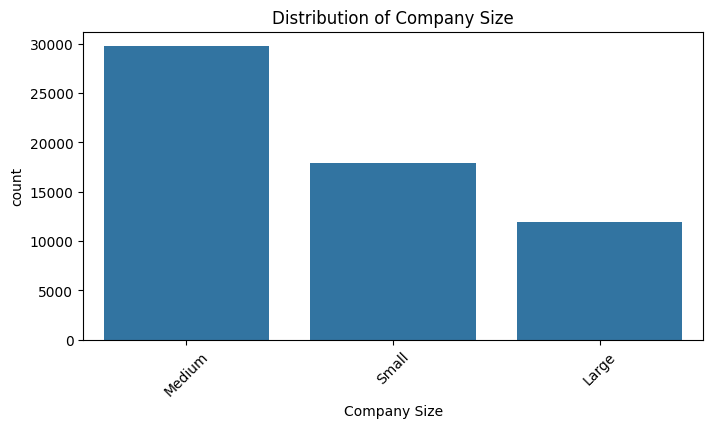

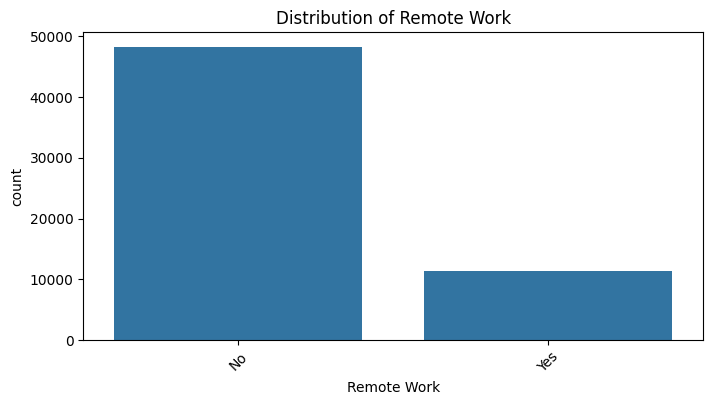

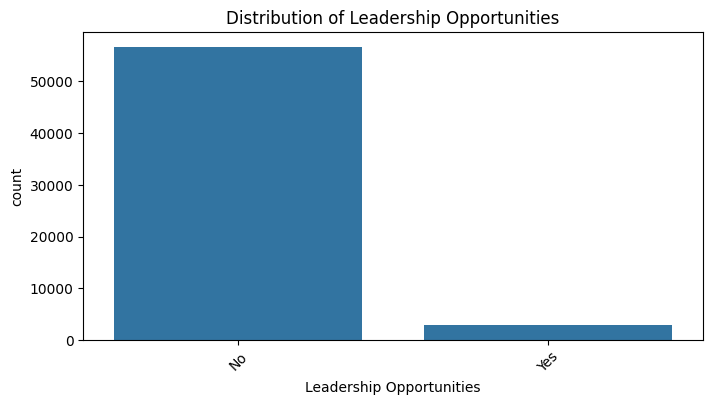

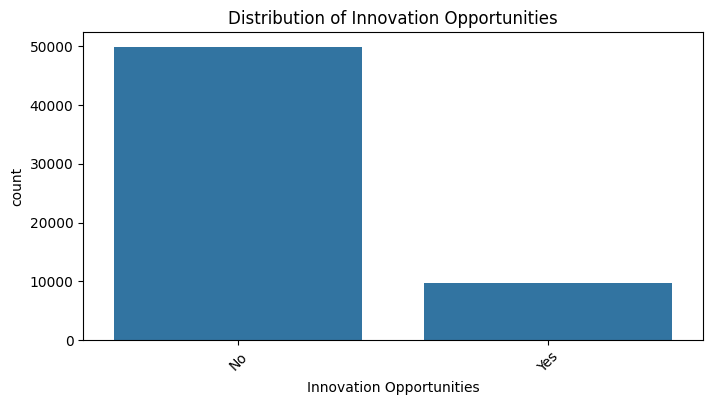

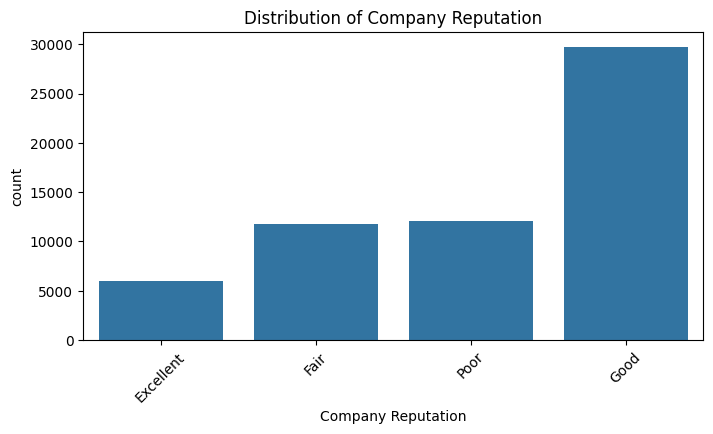

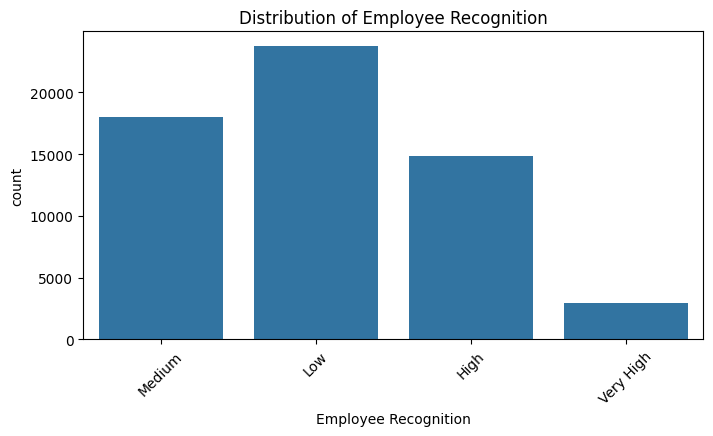

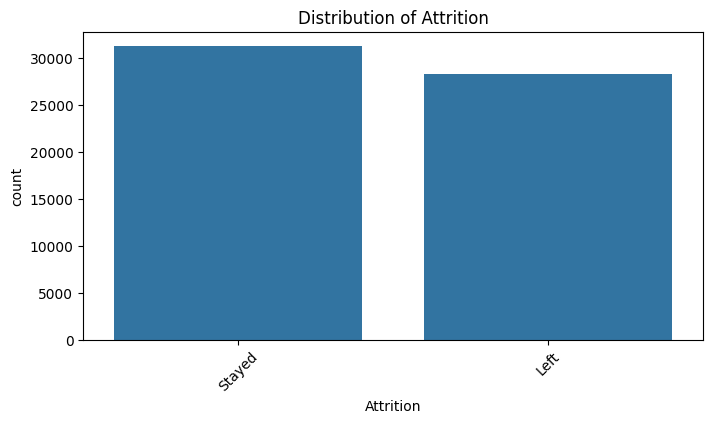

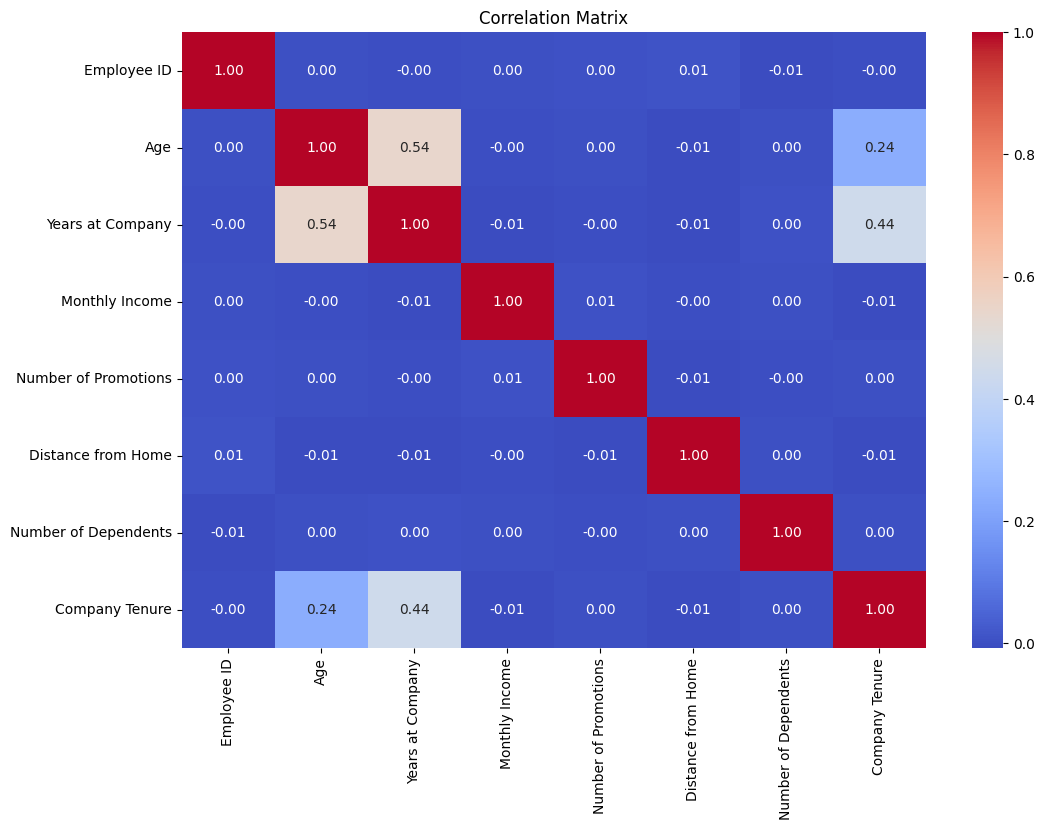

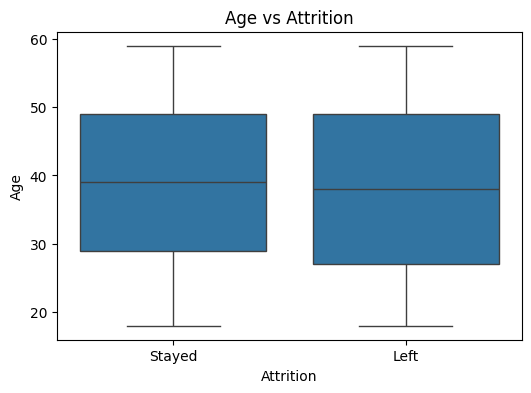

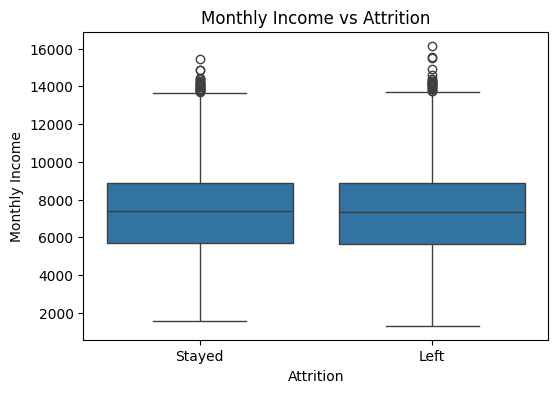

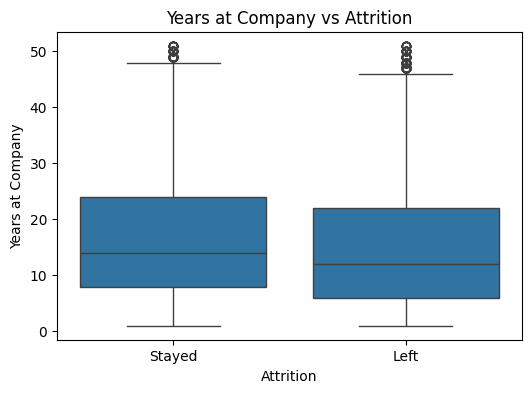

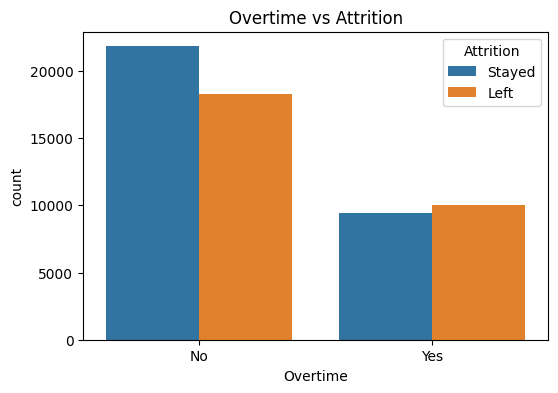

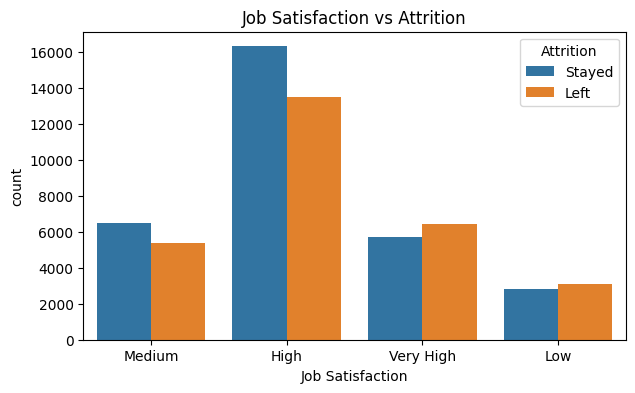

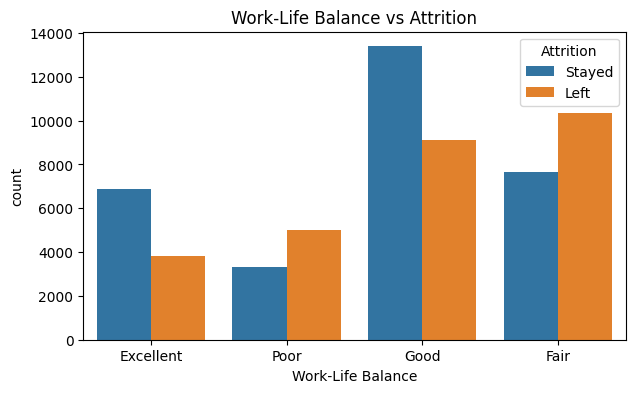

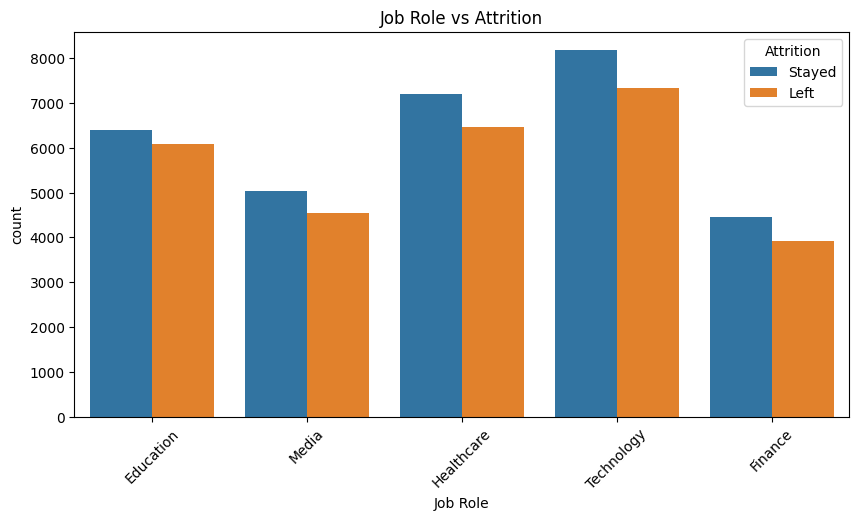

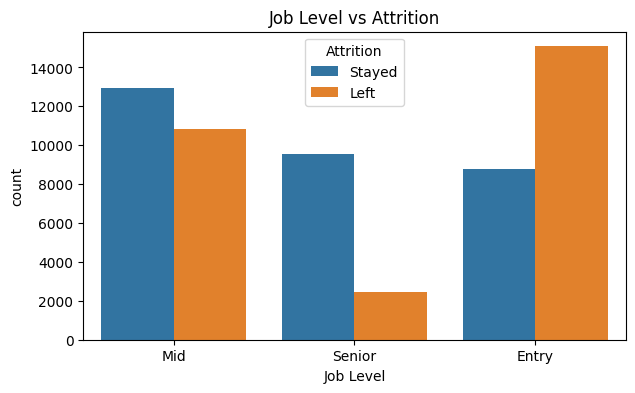

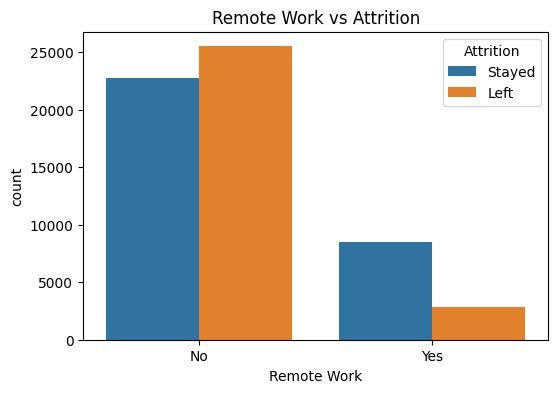

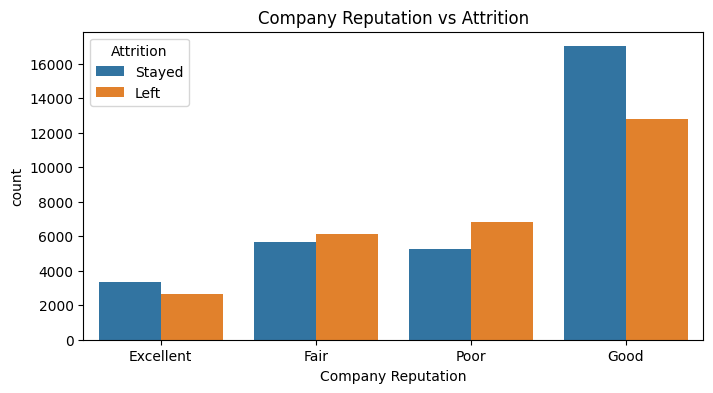

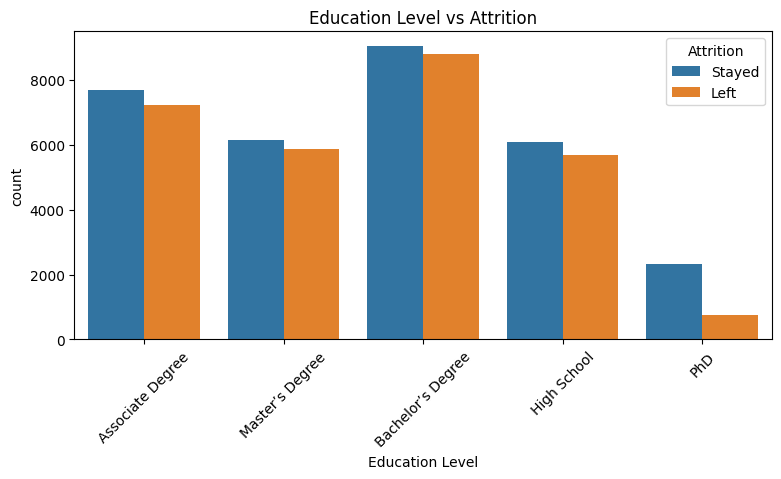

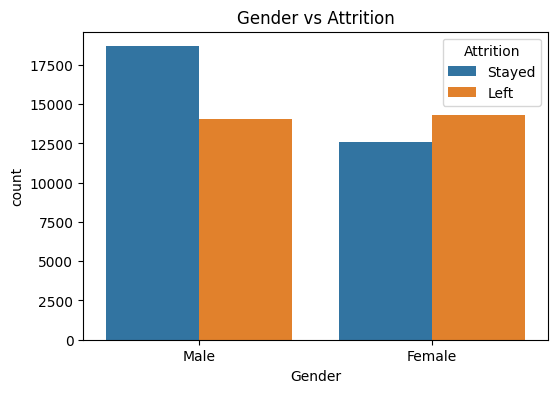

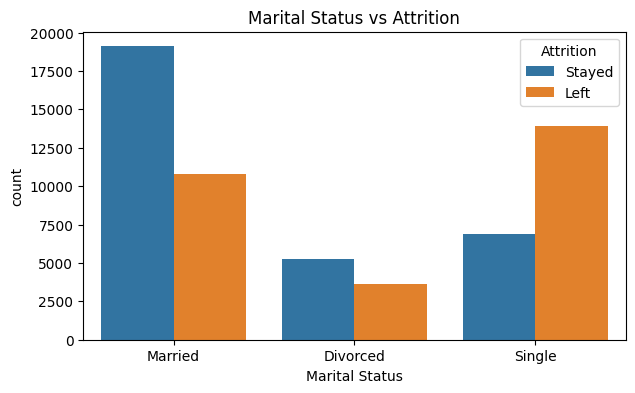

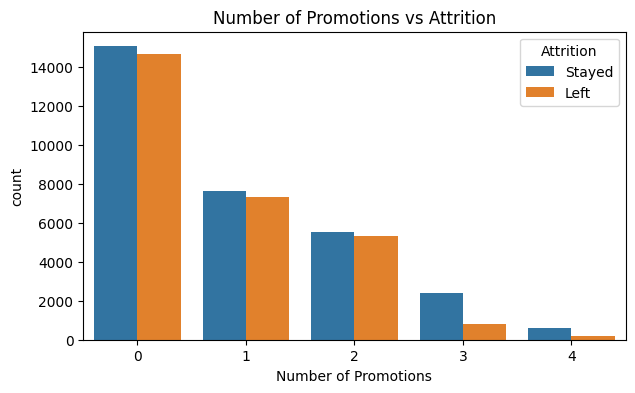

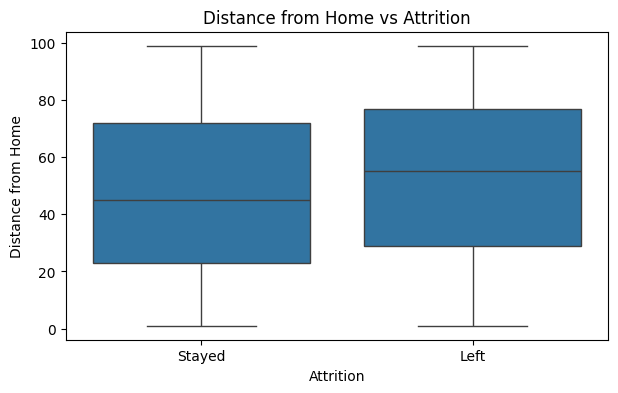

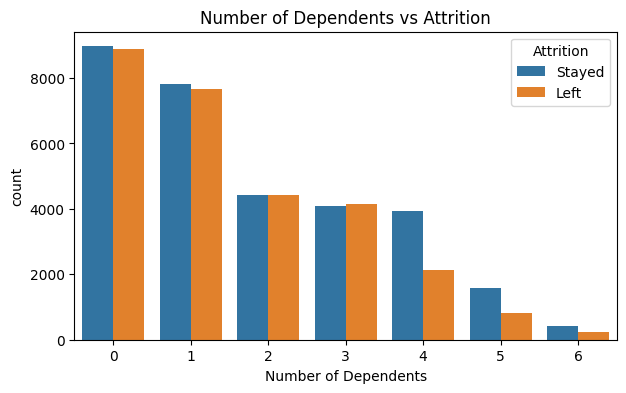


Overtime vs Attrition:
Attrition       Left     Stayed
Overtime                       
No         45.613729  54.386271
Yes        51.542416  48.457584

Job Satisfaction vs Attrition:
Attrition              Left     Stayed
Job Satisfaction                      
High              45.297021  54.702979
Low               52.418944  47.581056
Medium            45.324532  54.675468
Very High         52.885806  47.114194

Work-Life Balance vs Attrition:
Attrition               Left     Stayed
Work-Life Balance                      
Excellent          35.814908  64.185092
Fair               57.464258  42.535742
Good               40.558416  59.441584
Poor               60.108368  39.891632

Job Role vs Attrition:
Attrition        Left     Stayed
Job Role                        
Education   48.718975  51.281025
Finance     46.797853  53.202147
Healthcare  47.309779  52.690221
Media       47.440986  52.559014
Technology  47.288321  52.711679

========== EDA SUMMARY ==========
Dataset Shape: (595

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 2. LOAD DATASET
# =========================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Use train dataset for EDA
df = train.copy()

# =========================
# 3. BASIC INFORMATION
# =========================

print("Shape of Dataset:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())

# =========================
# 4. CHECK MISSING VALUES
# =========================

print("\nMissing Values:")
print(df.isnull().sum())

print("\nMissing Value Percentage:")
print((df.isnull().sum() / len(df)) * 100)

# =========================
# 5. CHECK DUPLICATES
# =========================

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# =========================
# 6. STATISTICAL SUMMARY
# =========================

print("\nNumerical Statistics:")
print(df.describe())

print("\nCategorical Statistics:")
print(df.describe(include="object"))

# =========================
# 7. UNIQUE VALUES
# =========================

print("\nUnique Values in Each Column:")

for col in df.columns:
    print(col, ":", df[col].nunique())

# =========================
# 8. ATTRITION DISTRIBUTION
# =========================

print("\nAttrition Count:")
print(df["Attrition"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

# =========================
# 9. ATTRITION PERCENTAGE
# =========================

attrition_percentage = df["Attrition"].value_counts(normalize=True) * 100

print("\nAttrition Percentage:")
print(attrition_percentage)

# =========================
# 10. NUMERICAL COLUMNS
# =========================

numeric_cols = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns:")
print(list(numeric_cols))

# Histograms
df[numeric_cols].hist(figsize=(15,12), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

# =========================
# 11. BOXPLOTS FOR NUMERICAL FEATURES
# =========================

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title("Boxplot of " + col)
    plt.show()

# =========================
# 12. CATEGORICAL COLUMNS
# =========================

categorical_cols = df.select_dtypes(include="object").columns

print("\nCategorical Columns:")
print(list(categorical_cols))

# =========================
# 13. CATEGORICAL DISTRIBUTIONS
# =========================

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title("Distribution of " + col)
    plt.xticks(rotation=45)
    plt.show()

# =========================
# 14. CORRELATION MATRIX
# =========================

plt.figure(figsize=(12,8))

correlation = df[numeric_cols].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# =========================
# 15. AGE VS ATTRITION
# =========================

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Attrition", y="Age")
plt.title("Age vs Attrition")
plt.show()

# =========================
# 16. MONTHLY INCOME VS ATTRITION
# =========================

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Attrition", y="Monthly Income")
plt.title("Monthly Income vs Attrition")
plt.show()

# =========================
# 17. YEARS AT COMPANY VS ATTRITION
# =========================

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Attrition", y="Years at Company")
plt.title("Years at Company vs Attrition")
plt.show()

# =========================
# 18. OVERTIME VS ATTRITION
# =========================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Overtime", hue="Attrition")
plt.title("Overtime vs Attrition")
plt.show()

# =========================
# 19. JOB SATISFACTION VS ATTRITION
# =========================

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Job Satisfaction", hue="Attrition")
plt.title("Job Satisfaction vs Attrition")
plt.show()

# =========================
# 20. WORK-LIFE BALANCE VS ATTRITION
# =========================

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Work-Life Balance", hue="Attrition")
plt.title("Work-Life Balance vs Attrition")
plt.show()

# =========================
# 21. JOB ROLE VS ATTRITION
# =========================

plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Job Role", hue="Attrition")
plt.title("Job Role vs Attrition")
plt.xticks(rotation=45)
plt.show()

# =========================
# 22. JOB LEVEL VS ATTRITION
# =========================

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Job Level", hue="Attrition")
plt.title("Job Level vs Attrition")
plt.show()

# =========================
# 23. REMOTE WORK VS ATTRITION
# =========================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Remote Work", hue="Attrition")
plt.title("Remote Work vs Attrition")
plt.show()

# =========================
# 24. COMPANY REPUTATION VS ATTRITION
# =========================

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Company Reputation", hue="Attrition")
plt.title("Company Reputation vs Attrition")
plt.show()

# =========================
# 25. EDUCATION LEVEL VS ATTRITION
# =========================

plt.figure(figsize=(9,4))
sns.countplot(data=df, x="Education Level", hue="Attrition")
plt.title("Education Level vs Attrition")
plt.xticks(rotation=45)
plt.show()

# =========================
# 26. GENDER VS ATTRITION
# =========================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Attrition")
plt.title("Gender vs Attrition")
plt.show()

# =========================
# 27. MARITAL STATUS VS ATTRITION
# =========================

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Marital Status", hue="Attrition")
plt.title("Marital Status vs Attrition")
plt.show()

# =========================
# 28. PROMOTIONS VS ATTRITION
# =========================

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Number of Promotions", hue="Attrition")
plt.title("Number of Promotions vs Attrition")
plt.show()

# =========================
# 29. DISTANCE FROM HOME VS ATTRITION
# =========================

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Attrition", y="Distance from Home")
plt.title("Distance from Home vs Attrition")
plt.show()

# =========================
# 30. DEPENDENTS VS ATTRITION
# =========================

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Number of Dependents", hue="Attrition")
plt.title("Number of Dependents vs Attrition")
plt.show()

# =========================
# 31. CROSS TABULATION
# =========================

print("\nOvertime vs Attrition:")
print(pd.crosstab(df["Overtime"], df["Attrition"], normalize="index") * 100)

print("\nJob Satisfaction vs Attrition:")
print(pd.crosstab(df["Job Satisfaction"], df["Attrition"], normalize="index") * 100)

print("\nWork-Life Balance vs Attrition:")
print(pd.crosstab(df["Work-Life Balance"], df["Attrition"], normalize="index") * 100)

print("\nJob Role vs Attrition:")
print(pd.crosstab(df["Job Role"], df["Attrition"], normalize="index") * 100)

# =========================
# 32. FINAL SUMMARY
# =========================

print("\n========== EDA SUMMARY ==========")

print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

print("\nAttrition Distribution:")
print(df["Attrition"].value_counts())

print("\nNumerical Columns:")
print(list(numeric_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))